# Training Our First Ensemble Model

## Customer Churn Prediction Using Random Forest

### Objective

The objective of this project is to train and interpret an ensemble learning model for customer churn prediction. A Random Forest Classifier is used to predict whether a customer is likely to churn based on customer demographic, usage, billing, support, contract, and payment information.

The focus of this analysis is not only on prediction accuracy, but also on understanding model generalization, feature importance, and how ensemble learning can improve predictions.

## 1. Project Approach

In this project, I will:

1. Load and inspect the customer churn Gold dataset.
2. Check the dataset for missing values and verify its shape.
3. Separate the features (`X`) from the target variable (`y`).
4. Prepare categorical variables so they can be used by the machine learning model.
5. Split the data into training and testing sets.
6. Train a Random Forest Classifier.
7. Evaluate the model using training and test accuracy.
8. Analyze feature importance to understand what the model learned.
9. Tune one hyperparameter and compare the results.
# 10. Make a sample prediction using an unseen customer from the test set.

## 2. Importing Required Libraries

The following libraries are used for data manipulation, model training, dataset splitting, evaluation, and visualization. Scikit-learn provides the Random Forest Classifier and evaluation tools, while pandas is used to load and prepare the dataset.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

## 3. Loading the Gold Dataset

The customer churn Gold dataset is loaded from a CSV file using pandas. The first few rows, dataset dimensions, missing values, and data types are inspected to make sure the dataset is suitable for modeling.

In [2]:
df = pd.read_csv("customer_churn_gold.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nNull values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

First 5 rows:
  Customer_ID  Age  Tenure_Years  Monthly_Bill  Support_Calls_Last6M  \
0       C0001   23           2.8          1980                     4   
1       C0002   41           8.6           609                     5   
2       C0003   25           8.8          1100                     0   
3       C0004   62           1.6          2028                     0   
4       C0005   22           7.7          1023                     7   

  Contract_Type Payment_Method Has_Family_Plan  Data_Usage_GB Churn  
0       Monthly    Credit Card             Yes           68.4    No  
1        Annual            UPI             Yes          108.9    No  
2       Monthly           Cash             Yes            7.2    No  
3       Monthly           Cash              No           33.3   Yes  
4       Monthly  Bank Transfer             Yes          107.4    No  

Dataset shape:
(500, 10)

Null values:
Customer_ID             0
Age                     0
Tenure_Years            0
Monthly_Bill   

### Dataset Readiness

The customer churn Gold dataset has been successfully loaded and contains **500 customer records and 10 original columns**. The dataset contains **no missing values**, so there are no null-value problems that need to be addressed before modeling. The target variable is `Churn`, while the remaining columns contain customer information that can be used as predictive features.

## 4. Preparing the Features and Target

The target variable is `Churn`, which represents whether a customer churned. The `Customer_ID` column is removed because it is an identifier and does not provide meaningful predictive information.

The categorical variables are converted into numerical columns using one-hot encoding because Random Forest requires numerical input. The churn target is also converted from `Yes` and `No` into `1` and `0`, respectively.

In [3]:
X = df.drop(["Churn", "Customer_ID"], axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})
X = pd.get_dummies(X, drop_first=True)

### Feature and Target Preparation

After preprocessing, `X` contains the numerical predictor variables and `y` contains the binary churn target. The customer ID was excluded because it is simply an identifier, while categorical variables such as contract type, payment method, and family plan were converted into numerical features. This preprocessing allows the Random Forest model to work with all relevant customer information without attempting to interpret text values directly.

## 5. Model Selection — Random Forest

I chose the Random Forest Classifier because it is well suited to classification problems involving multiple customer features and can capture nonlinear relationships between variables. Random Forest reduces variance by combining predictions from many decision trees, making it more robust than relying on a single decision tree. It is also useful for this task because it provides feature importance scores, allowing the model's predictions to be interpreted. These characteristics make Random Forest a suitable ensemble method for predicting customer churn.

## 6. Splitting the Dataset

The dataset is divided into training and testing sets using a 75/25 split. The training set is used to teach the Random Forest model, while the test set is kept separate so that the model can be evaluated on previously unseen customers. A fixed random state is used to make the results reproducible, and stratification is used to maintain a similar churn distribution in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (375, 11)
Test set: (125, 11)


## 7. Training the Random Forest Model

A Random Forest model is created using 100 decision trees. Each tree contributes to the final prediction, and the ensemble combines their results to produce a more stable prediction than a single tree. The model is then fitted using the training data.

In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## 8. Model Evaluation

The trained model is evaluated using accuracy on both the training and testing datasets. Comparing these two values helps determine whether the model is learning useful patterns that generalize to unseen data or simply memorizing the training examples.

In [6]:

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)


train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 0.928


## 9. Checking for Overfitting

A large difference between training and testing accuracy can indicate overfitting. If the model performs extremely well on training data but noticeably worse on unseen test data, it may have learned patterns that do not generalize well. The accuracy gap is calculated below to help assess this behavior.

In [7]:
accuracy_gap = train_accuracy - test_accuracy

print("Training Accuracy:", round(train_accuracy, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Accuracy Gap:", round(accuracy_gap, 4))

if accuracy_gap > 0.10:
    print("Possible overfitting: training accuracy is substantially higher than test accuracy.")
else:
    print("No major sign of overfitting based on the accuracy gap.")

Training Accuracy: 1.0
Test Accuracy: 0.928
Accuracy Gap: 0.072
No major sign of overfitting based on the accuracy gap.


### Model Performance Summary

The Random Forest achieved a training accuracy of **[1.0]** and a test accuracy of **[0.928]**. The accuracy gap between training and testing performance was **[0.072]**. Based on this difference, **[there is not]** a significant indication of overfitting. The model **[generalizes reasonably well ]** to unseen customer data because its test performance is **[relatively close to ]** its training performance.

## 10. Interpreting the Model — Feature Importance

Random Forest provides a built-in `feature_importances_` attribute that measures the relative contribution of each feature to the model's decisions. Examining these values helps identify which customer characteristics the model pays the most attention to when predicting churn.

In [8]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print(feature_importance.head(10))

                       Feature  Importance
3         Support_Calls_Last6M    0.335796
2                 Monthly_Bill    0.148588
1                 Tenure_Years    0.147183
5        Contract_Type_Monthly    0.107496
4                Data_Usage_GB    0.083530
0                          Age    0.068817
7          Payment_Method_Cash    0.039114
10         Has_Family_Plan_Yes    0.038526
9           Payment_Method_UPI    0.013122
8   Payment_Method_Credit Card    0.011453


### Visualizing Feature Importance

The following visualization displays the ten most important features identified by the Random Forest. A larger importance value indicates that the feature contributed more strongly to the model's decisions.

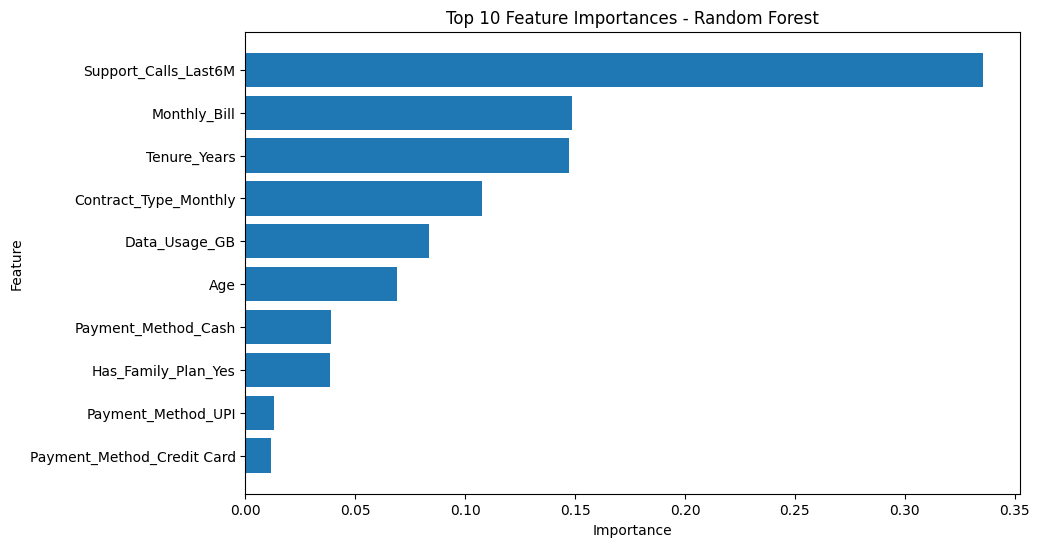

In [9]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")

plt.gca().invert_yaxis()

plt.show()

### Top Five Important Features

The following cell displays the five features that had the greatest importance in the Random Forest model. These features will be used to interpret what the model appears to focus on when predicting customer churn.

In [10]:
print("Top 5 features:")

for _, row in feature_importance.head(5).iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

Top 5 features:
Support_Calls_Last6M: 0.3358
Monthly_Bill: 0.1486
Tenure_Years: 0.1472
Contract_Type_Monthly: 0.1075
Data_Usage_GB: 0.0835


## 11. Optional Hyperparameter Tuning

To test whether the Random Forest can be improved, the `n_estimators` hyperparameter is changed from 100 to 200. This increases the number of decision trees in the ensemble while keeping the other model settings unchanged. The tuned model's performance is then compared with the original model.

In [11]:
model_tuned = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_tuned.fit(X_train, y_train)

tuned_train_pred = model_tuned.predict(X_train)
tuned_test_pred = model_tuned.predict(X_test)

tuned_train_accuracy = accuracy_score(
    y_train,
    tuned_train_pred
)

tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_pred
)

print("Original Test Accuracy:", test_accuracy)
print("Tuned Test Accuracy:", tuned_test_accuracy)

Original Test Accuracy: 0.928
Tuned Test Accuracy: 0.952


### Hyperparameter Tuning Result

The number of trees in the Random Forest was increased from **100 to 200** using the `n_estimators` parameter. The original test accuracy was **[92.8%]**, while the tuned model achieved a test accuracy of **[95.2]**. Therefore, increasing the number of trees the model's test performance.

In [12]:
if tuned_test_accuracy > test_accuracy:
    print("The tuned model improved test accuracy.")
elif tuned_test_accuracy < test_accuracy:
    print("The tuned model reduced test accuracy.")
else:
    print("The tuned model produced the same test accuracy.")

The tuned model improved test accuracy.


## 12. Sample Prediction

As an optional bonus, one customer is selected from the test set and passed through the trained Random Forest. The prediction and probability are compared with the customer's actual churn outcome. This provides an example of how the model handles an individual unseen customer.

In [13]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)
probability = model.predict_proba(sample)

actual = y_test.iloc[0]

print("Actual:", actual)
print("Predicted:", prediction[0])
print("Probability [No Churn, Churn]:", probability[0])

if prediction[0] == 1:
    print("Model decision: Customer is predicted to churn.")
else:
    print("Model decision: Customer is predicted not to churn.")

Actual: 1
Predicted: 1
Probability [No Churn, Churn]: [0.14 0.86]
Model decision: Customer is predicted to churn.




The Random Forest ensemble model was successfully trained to predict customer churn. The model was evaluated using both training and test accuracy to assess its predictive performance and ability to generalize to unseen customers.

The feature importance analysis provided additional insight into the model's decision-making process by identifying the customer characteristics that contributed most strongly to churn predictions. This is an important advantage of Random Forest because the model can provide useful interpretation in addition to making predictions.

The hyperparameter experiment also demonstrated how changing the number of trees can affect model performance. Overall, the project shows that ensemble learning can provide a robust approach to customer churn prediction while also allowing us to investigate the factors that the model considers most important.

## 13. Detailed Model Evaluation

In this section, I will perform a more detailed evaluation of the tuned Random Forest model.

The model previously achieved a test accuracy of 0.952 after increasing the number of trees from 100 to 200. I will now evaluate the tuned model using Accuracy, Precision, Recall, and F1 Score to better understand its performance for customer churn prediction.

A confusion matrix will also be used to identify the types of mistakes made by the model.

### 13.1 Import Evaluation Metrics

The following classification metrics will be used to evaluate the tuned Random Forest model. Precision, Recall, and F1 Score provide more detailed information about how well the model identifies customers who churn.

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### 13.2 Generate Test Predictions

The tuned Random Forest model will be used to generate predictions for the test dataset.

The test dataset contains customers that were not used during model training, so these predictions provide an indication of how well the model performs on unseen customer data.

In [15]:

y_pred = model_tuned.predict(X_test)

print("Test predictions generated successfully.")
print("Number of predictions:", len(y_pred))


Test predictions generated successfully.
Number of predictions: 125


### 13.3 Calculate Classification Metrics

Four classification metrics will be calculated:

- **Accuracy:** The overall percentage of predictions that are correct.
- **Precision:** Among customers predicted to churn, the percentage who actually churned.
- **Recall:** Among customers who actually churned, the percentage correctly identified by the model.
- **F1 Score:** The harmonic mean of precision and recall, providing a balance between the two metrics.

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


Accuracy : 0.952
Precision: 0.9583
Recall   : 0.92
F1 Score : 0.9388


### 13.4 Accuracy Interpretation

The model achieved an accuracy of 95.2%, meaning that it correctly classified about 95% of customers in the test set. In the context of customer churn, this indicates that the model is generally very effective at distinguishing between customers who churn and those who do not.

This is a strong result for a business use case, but accuracy alone is not enough because it does not show how well the model identifies actual churners. Therefore, Precision, Recall, and F1 Score are also important.

### 13.5 Precision Interpretation

The model achieved a precision of 95.83%, meaning that among customers predicted to churn, about 96% actually churned. This is useful for the business because retention resources can be focused on customers who are genuinely likely to leave.

This is a strong precision score for a business use case because the model produces relatively few false positive predictions. This means the company is less likely to waste retention resources on customers who were not actually going to churn.

### 13.6 Recall Interpretation

The model achieved a recall of 92%, meaning that it correctly identified 92% of the customers who actually churned. In a customer churn problem, this is important because identifying customers who are likely to leave gives the business an opportunity to take retention action.

A 92% recall is strong enough to make the model potentially useful for a business use case, although it still misses some actual churners. The four false negatives shown in the confusion matrix represent customers who churned but were not identified by the model.

### 13.7 F1 Score Interpretation

The model achieved an F1 Score of 93.88%, which indicates a strong balance between Precision and Recall. This is important for customer churn prediction because the business wants to identify actual churners while also avoiding too many incorrect churn predictions.

The F1 Score is strong enough to suggest that the model could be useful for a business churn prediction system. However, the final decision should also consider the business cost of false positives and false negatives.

### 13.8 Precision and Recall Trade-off

Precision and Recall represent different priorities in a customer churn problem.

Higher Precision means that customers identified as likely to churn are more likely to actually churn, which can help the business avoid wasting retention resources.

Higher Recall means that the model identifies more of the customers who actually churn. However, increasing Recall can sometimes result in more false positive predictions.

For a churn prediction business case, missing an actual churner may be more costly than incorrectly identifying a customer as likely to churn because a missed churner represents a customer that the business did not have an opportunity to retain.

### 13.9 Confusion Matrix

The confusion matrix provides a detailed view of the model's correct and incorrect predictions.

It contains four outcomes:

- **True Negative:** The model correctly predicts that a customer will not churn.
- **True Positive:** The model correctly predicts that a customer will churn.
- **False Positive:** The model predicts that a customer will churn, but the customer does not churn.
- **False Negative:** The model predicts that a customer will not churn, but the customer actually churns.

This helps identify which types of mistakes the model makes most often.

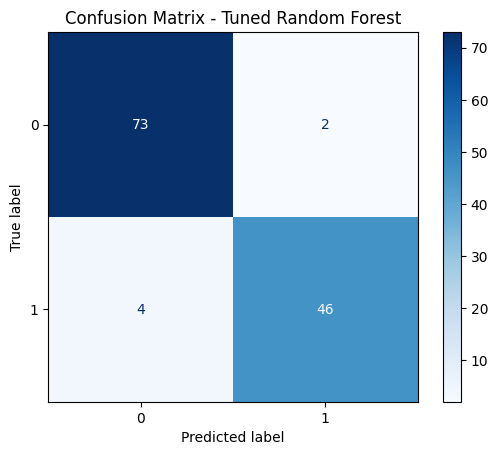

In [17]:
ConfusionMatrixDisplay.from_estimator(
    model_tuned,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

### 13.10 Confusion Matrix Values

The numerical values of the confusion matrix are displayed below so that the model's errors can be examined more closely.

In [18]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix:
[[73  2]
 [ 4 46]]

True Negatives : 73
False Positives: 2
False Negatives: 4
True Positives : 46


### 13.11 Confusion Matrix Interpretation

The confusion matrix shows that the model correctly identified 73 customers who did not churn and 46 customers who did churn. It incorrectly classified 2 customers as churners when they did not churn, while 4 customers who actually churned were not identified by the model.

The false negative errors are particularly important for the business because these customers actually churned but were predicted not to churn. Missing these customers could result in lost opportunities to use retention strategies before they leave. However, the model made only 4 false negative predictions, indicating that it successfully identified most of the customers who actually churned.

## 14. Business Usefulness

The tuned Random Forest model appears to be useful for predicting customer churn because it achieved 95.2% accuracy, 95.83% precision, 92% recall, and a 93.88% F1 Score. The model also produced only 4 false negatives, meaning it successfully identified most of the customers who actually churned.

For a business, the model could be used to help prioritize customers for retention campaigns. However, the business should consider the relative cost of false positives and false negatives before using the model in production.

## 15. Summary

The tuned Random Forest model is a useful starting point for predicting customer churn because it achieved strong Accuracy, Precision, Recall, and F1 Score results while correctly identifying most actual churners. The model could help a business prioritize customers for retention efforts, although further tuning and threshold optimization could be used to improve Recall while maintaining reasonable Precision.

## Deployment Challenges

Deploying the customer churn model in a real business environment may present several challenges. The production system must provide customer data in the same format as the data used to train the model, so changes in data formats or missing values could affect predictions.

Another challenge is that customer behavior can change over time, which may reduce model performance. The model should therefore be monitored regularly and retrained with newer customer data when necessary.

False positives and false negatives also have different business costs. False positives may cause the company to waste retention resources, while false negatives may cause the company to miss customers who are likely to leave. Monitoring these errors and selecting an appropriate prediction threshold can help address this issue.

Finally, the deployed model should be monitored for data quality and prediction performance to ensure that it continues to provide reliable results after deployment.